# **Burnout Prediction ML Project**
---
## **1. IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, StackingClassifier

## **2. LOAD DATA**

In [ ]:
df = pd.read_csv("/Data/tech_mental_health_burnout.csv")

## **3. BASIC EXPLORATION**

In [3]:
df.head()

,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,...,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      150000 non-null  int64  
 1   gender                   150000 non-null  object 
 2   job_role                 150000 non-null  object 
 3   experience_years         150000 non-null  float64
 4   company_size             150000 non-null  object 
 5   work_mode                150000 non-null  object 
 6   work_hours_per_week      150000 non-null  float64
 7   overtime_hours           150000 non-null  float64
 8   meetings_per_day         150000 non-null  float64
 9   deadlines_missed         150000 non-null  int64  
 10  job_satisfaction         150000 non-null  float64
 11  manager_support          150000 non-null  float64
 12  work_life_balance        150000 non-null  float64
 13  sleep_hours              150000 non-null  float64
 14  phys

In [5]:
df.shape

(150000, 25)

In [6]:
df.describe()

,age,experience_years,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,seeks_professional_help
count,150000.000000,150000.000000,150000.00000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,38.025340,5.055010,47.00758,6.127180,4.010893,1.284193,5.500248,5.497537,5.016357,6.499120,2.599833,8.002713,2.101693,5.498163,0.251133,5.785428,4.523763,3.096687,2.114121,0.096333
std,9.510609,2.878602,7.89331,3.783618,1.978316,1.426264,1.956102,1.956915,1.948553,1.192343,1.814880,1.987813,1.300247,1.957432,0.433667,1.331506,1.201506,1.187668,1.112614,0.295049
min,22.000000,0.000000,30.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,0.000000,3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,30.000000,3.000000,42.00000,3.000000,3.000000,0.000000,4.200000,4.100000,3.700000,5.700000,1.000000,6.700000,1.000000,4.200000,0.000000,4.900000,3.700000,2.200000,1.000000,0.000000
50%,38.000000,5.000000,47.00000,6.000000,4.000000,1.000000,5.500000,5.500000,5.000000,6.500000,2.000000,8.000000,2.000000,5.500000,0.000000,5.800000,4.500000,3.100000,1.900000,0.000000
75%,46.000000,7.000000,52.00000,9.000000,5.000000,2.000000,6.900000,6.800000,6.400000,7.300000,4.000000,9.300000,3.000000,6.800000,1.000000,6.700000,5.300000,3.900000,2.800000,0.000000
max,54.000000,18.500000,84.00000,24.000000,12.000000,5.000000,10.000000,10.000000,10.000000,10.000000,7.000000,16.000000,5.000000,10.000000,1.000000,10.000000,9.600000,8.100000,8.100000,1.000000


In [7]:
df.describe()

,age,experience_years,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,seeks_professional_help
count,150000.000000,150000.000000,150000.00000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,38.025340,5.055010,47.00758,6.127180,4.010893,1.284193,5.500248,5.497537,5.016357,6.499120,2.599833,8.002713,2.101693,5.498163,0.251133,5.785428,4.523763,3.096687,2.114121,0.096333
std,9.510609,2.878602,7.89331,3.783618,1.978316,1.426264,1.956102,1.956915,1.948553,1.192343,1.814880,1.987813,1.300247,1.957432,0.433667,1.331506,1.201506,1.187668,1.112614,0.295049
min,22.000000,0.000000,30.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,0.000000,3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,30.000000,3.000000,42.00000,3.000000,3.000000,0.000000,4.200000,4.100000,3.700000,5.700000,1.000000,6.700000,1.000000,4.200000,0.000000,4.900000,3.700000,2.200000,1.000000,0.000000
50%,38.000000,5.000000,47.00000,6.000000,4.000000,1.000000,5.500000,5.500000,5.000000,6.500000,2.000000,8.000000,2.000000,5.500000,0.000000,5.800000,4.500000,3.100000,1.900000,0.000000
75%,46.000000,7.000000,52.00000,9.000000,5.000000,2.000000,6.900000,6.800000,6.400000,7.300000,4.000000,9.300000,3.000000,6.800000,1.000000,6.700000,5.300000,3.900000,2.800000,0.000000
max,54.000000,18.500000,84.00000,24.000000,12.000000,5.000000,10.000000,10.000000,10.000000,10.000000,7.000000,16.000000,5.000000,10.000000,1.000000,10.000000,9.600000,8.100000,8.100000,1.000000


In [8]:
df.isnull().sum()

age                        0
gender                     0
job_role                   0
experience_years           0
company_size               0
work_mode                  0
work_hours_per_week        0
overtime_hours             0
meetings_per_day           0
deadlines_missed           0
job_satisfaction           0
manager_support            0
work_life_balance          0
sleep_hours                0
physical_activity_days     0
screen_time_hours          0
caffeine_intake            0
social_support_score       0
has_therapy                0
stress_level               0
anxiety_score              0
depression_score           0
burnout_score              0
burnout_level              0
seeks_professional_help    0
dtype: int64

## **4. TARGET ANALYSIS**

In [9]:
df["burnout_level"].value_counts()

burnout_level
Low         131620
Moderate     18315
High            65
Name: count, dtype: int64

In [10]:
df["seeks_professional_help"].value_counts()

seeks_professional_help
0    135550
1     14450
Name: count, dtype: int64

## **5. BASIC VISUALIZATION**

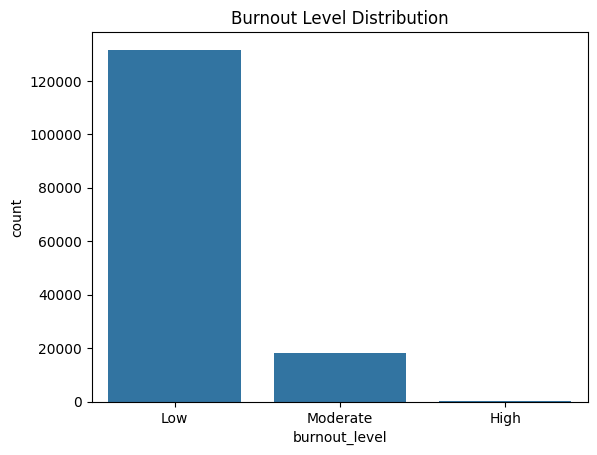

In [11]:
plt.figure()
sns.countplot(data=df, x="burnout_level")
plt.title("Burnout Level Distribution")
plt.show()

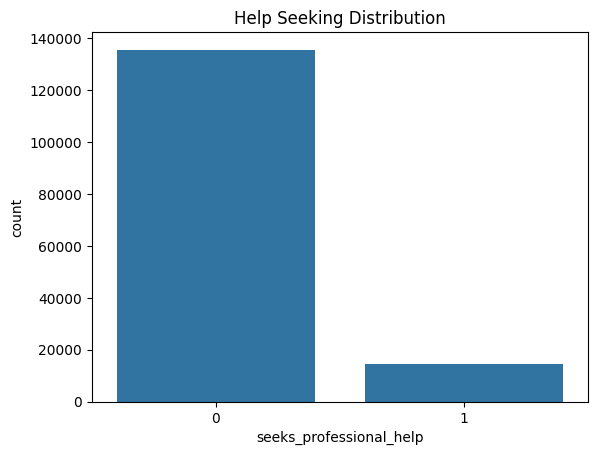

In [12]:
plt.figure()
sns.countplot(data=df, x="seeks_professional_help")
plt.title("Help Seeking Distribution")
plt.show()

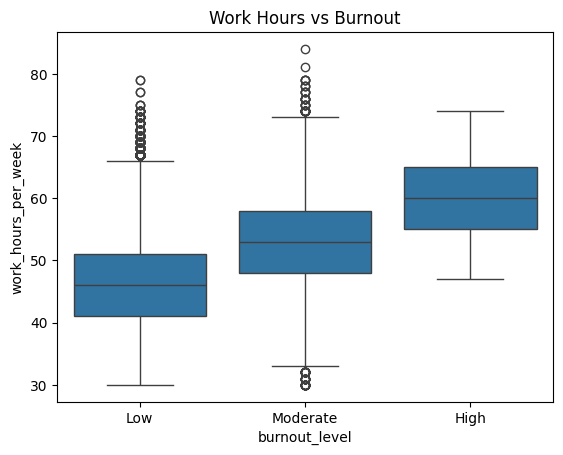

In [13]:
plt.figure()
sns.boxplot(data=df, x="burnout_level", y="work_hours_per_week")
plt.title("Work Hours vs Burnout")
plt.show()

In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

age                        0
gender                     0
job_role                   0
experience_years           0
company_size               0
work_mode                  0
work_hours_per_week        0
overtime_hours             0
meetings_per_day           0
deadlines_missed           0
job_satisfaction           0
manager_support            0
work_life_balance          0
sleep_hours                0
physical_activity_days     0
screen_time_hours          0
caffeine_intake            0
social_support_score       0
has_therapy                0
stress_level               0
anxiety_score              0
depression_score           0
burnout_score              0
burnout_level              0
seeks_professional_help    0
dtype: int64

## **6. FEATURE ENGINEERING**

In [16]:
df["burnout_level"] = df["burnout_level"].map({"Low":0, "Moderate":1, "High":2})
df["seeks_professional_help"] = df["seeks_professional_help"].astype(int)

## **7. FEATURES & TARGET**

In [17]:
X = df.drop(columns=["burnout_level", "seeks_professional_help"])
y = df["burnout_level"]

## **8. PREPROCESSING**

In [18]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

## **9. TRAIN TEST SPLIT**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **10. BASE MODELS**

In [20]:
log_reg = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier()

## **11. BAGGING MODE**

In [21]:
bagging_model = BaggingClassifier(
    estimator=RandomForestClassifier(),
    n_estimators=10,
    random_state=42
)

## **12. STACKING MODEL**

In [22]:
stacking_model = StackingClassifier(
    estimators=[
        ("lr", log_reg),
        ("rf", rf),
        ("gb", gb)
    ],
    final_estimator=LogisticRegression()
)

## **13. PIPELINE WRAPPER**

In [23]:
models = {
    "RandomForest": rf,
    "GradientBoosting": gb,
    "Bagging": bagging_model,
    "Stacking": stacking_model
}

results = {}

for name, model in models.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print("\n=====================")
    print(name)
    print(classification_report(y_test, y_pred))

    results[name] = accuracy_score(y_test, y_pred)


RandomForest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26324
           1       1.00      1.00      1.00      3663
           2       1.00      0.69      0.82        13

    accuracy                           1.00     30000
   macro avg       1.00      0.90      0.94     30000
weighted avg       1.00      1.00      1.00     30000


GradientBoosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26324
           1       1.00      1.00      1.00      3663
           2       1.00      1.00      1.00        13

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000


Bagging
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26324
           1       1.00      1.00      1.00      3663
           2       1.00      0.54 

## **14. MODEL COMPARISON**

In [24]:
print("\nMODEL ACCURACY COMPARISON")
for k, v in results.items():
    print(k, ":", v)


MODEL ACCURACY COMPARISON
RandomForest : 0.9998666666666667
GradientBoosting : 1.0
Bagging : 0.9998
Stacking : 1.0


## **15. SAMPLE PREDICTION (STACKING)**

In [25]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", stacking_model)
])

final_model.fit(X_train, y_train)

sample = X_test.iloc[:1]
print("Prediction:", final_model.predict(sample))
print("Actual:", y_test.iloc[:1].values)

Prediction: [0]
Actual: [0]


## **16. SAVE MODEL (.pkl)**

In [26]:
joblib.dump(final_model, "burnout_model.pkl")

print("Model saved successfully as burnout_model.pkl")

Model saved successfully as burnout_model.pkl
